In [1]:
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from textwrap import wrap
from matplotlib.font_manager import FontProperties
import re
from scipy import stats
from matplotlib.lines import Line2D 

line_size=0.5
custom_params = {
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': 'line',
    'axes.labelcolor': 'black',
    'figure.facecolor': 'white',
    "axes.spines.right": True, 
    "axes.spines.bottom": True,
    'xtick.direction': 'inout',
    'ytick.direction': 'in',
    'xtick.bottom': True,
    'xtick.minor.visible': False,
    'xtick.major.bottom':  True,
    'xtick.minor.bottom':  True,
    'xtick.major.pad':     7,     # distance to major tick label in points#
    'xtick.minor.pad':     3.4,     # distance to the minor tick label in points#
    'xtick.major.size':    10,
    'ytick.major.size':    4,
    'xtick.major.width':   line_size,
    'ytick.major.width':   line_size,
    'axes.linewidth': line_size,
    'xtick.minor.size':    2,
    'pdf.fonttype': 42}

sns.set_theme(style="ticks", rc=custom_params, font="Arial",font_scale=0.7)

enmax_palette = ["#648FFF", "#FE6100", "#785EF0", "#DC267F", "#FFB000"]
sns.set_palette(palette=enmax_palette)
warnings.filterwarnings("ignore")

In [2]:
filename = "Control_Pathway_Proteins.csv"
data = pd.read_csv(f'Figure_Data/{filename}')

In [3]:
df = pd.DataFrame(data)

In [4]:
import pandas as pd

# Assuming your dataframe is called df
df_melted = df.melt(
    id_vars=['DBTL_Cycle', 'Line_name', 'Line', 'Replicate'],
    value_vars=['mvaE', 'mvaS', 'MK', 'PMD*', 'AphA', 'dCas9'],
    var_name='Protein',
    value_name='Expression'
)

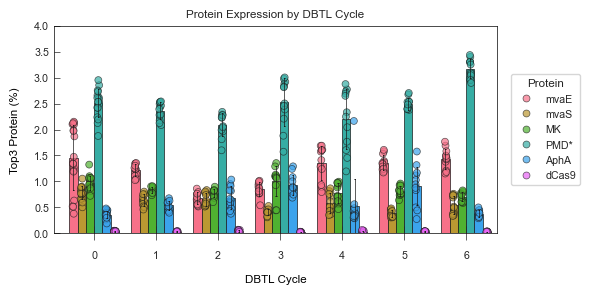

In [5]:
fig_name = "Fig_S15"
fig, ax = plt.subplots(figsize=(6, 3))

with sns.color_palette():
    sns.stripplot(
        data=df_melted, x="DBTL_Cycle", y="Expression",
        hue='Protein', dodge=True, alpha=0.7,
        linewidth=line_size, edgecolor="k", zorder=2, ax=ax
    )
    sns.barplot(
        data=df_melted, x="DBTL_Cycle", y="Expression",
        hue='Protein', errorbar="sd", zorder=0, capsize=0.1,
        linewidth=line_size, edgecolor="k", saturation=1,
        errwidth=line_size, errcolor ="k",
        dodge=True, ax=ax
    )

# Remove duplicate legends (since both stripplot and barplot add one)
handles, labels = ax.get_legend_handles_labels()
n_proteins = df_melted['Protein'].nunique()
ax.legend(handles[:n_proteins], labels[:n_proteins], title='Protein', loc='right',  bbox_to_anchor=(1.2, 0.5), ncol=1)

# Format axes and legend
ax.set_xlabel('DBTL Cycle', labelpad=10)
ax.set_ylabel('Top3 Protein (%)', labelpad=10)
ax.set_title('Protein Expression by DBTL Cycle')
ax.set_ylim(0, 4)
ax.set_xlim(-0.65, None)
ax.set_xticklabels(ax.get_xticklabels())

plt.tight_layout()
plt.savefig(f'Figure_Export/{fig_name}.pdf', dpi=1200, bbox_inches='tight')
plt.show()